## 0. 패키지 및 데이터 불러오기

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 데이터 구성 패키지:Series, DataFrame
import pandas as pd
# 행렬 연산 패키지
import numpy as np
from scipy.stats import shapiro

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt

# 데이터 시각화(추세 등) 패키지
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# 그래프 표시
%matplotlib inline

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/인도 중고차 /박주형/df_car.csv')
df

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6987,NaN,89411,0,1,1,20.54,1598.0,103.60,5.0,30,13,2,3
6988,NaN,59000,1,2,1,17.21,1197.0,103.60,5.0,30,9,2,2
6989,NaN,28000,0,1,1,23.08,1461.0,63.10,5.0,22,12,1,1
6990,NaN,52262,1,2,3,17.20,1197.0,103.60,5.0,30,11,2,2


In [ ]:
# df에서 price 결측치 제거
df_noprice = df.dropna(subset=['Price'])

In [ ]:
# 가격 데이터에 로그 변환 적용 (0이거나 음수인 값이 없다고 가정)
df['log_price'] = np.log1p(df['Price'])  # log1p는 1을 더한 후 로그 변환을 수행

# price 극단치 데이터 처리

# 'log_price' 열에 대한 Q1과 Q3 계산
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1

# IQR을 사용하여 이상치가 아닌 데이터의 범위 정의
lower_bound = Q1 - 1.5 * IQR

df= df[df['log_price'] >= lower_bound ]

# Price 결측치 제거됨

In [ ]:
df.isnull().sum()

Price                0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Brand                0
Vehicle_Age          0
Brand_Group          0
city_location        0
log_price            0
dtype: int64

## Kilometers_Driven

In [ ]:
# 데이터 확인
df[['Kilometers_Driven']]

,Kilometers_Driven
0,72000
1,41000
2,46000
3,87000
4,40670
...,...
6964,36000
6967,41413
6970,39015
6971,6000


### Kilometers_Driven 분포

<Axes: xlabel='Kilometers_Driven', ylabel='Count'>

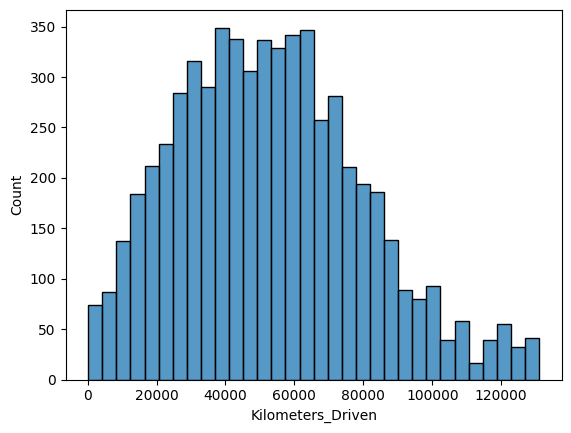

In [ ]:
# df.hist method 이용 : Kilometers_Driven에 대한 히스토그램 생성
sns.histplot(data=df, x="Kilometers_Driven")

### boxplot

<Axes: xlabel='Kilometers_Driven'>

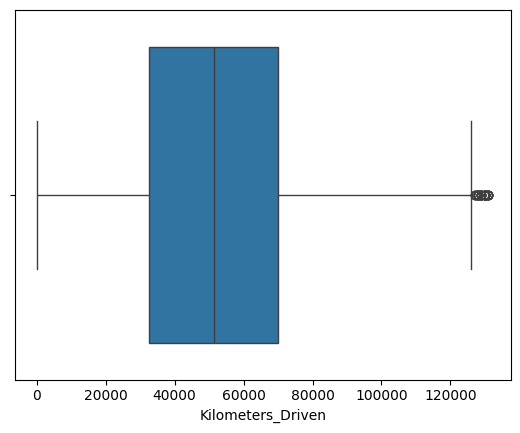

In [ ]:
# kilometer_Driven boxplot
sns.boxplot(x='Kilometers_Driven', data=df)

#### 1) mileage와의 비교

In [ ]:
# Min-Max Scaling 수행
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['Kilometers_Driven', 'Mileage']] = scaler.fit_transform(df[['Kilometers_Driven', 'Mileage']])

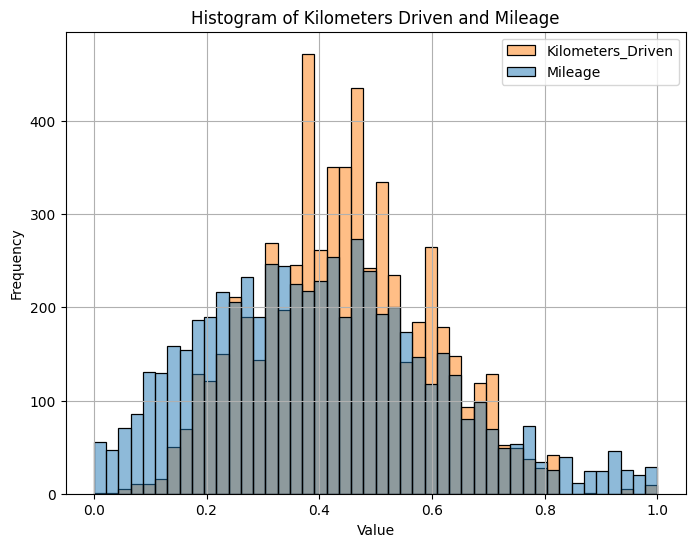

In [ ]:
# Kilometers_Driven와 Mileage를 하나의 데이터프레임으로 합치기
combined_df = pd.concat([df_scaled['Kilometers_Driven'], df_scaled['Mileage']], axis=1)

# 히스토그램 겹쳐 그리기
plt.figure(figsize=(8, 6))
sns.histplot(data=combined_df, color=['blue', 'red'], alpha=0.5)
plt.title('Histogram of Kilometers Driven and Mileage')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend(['Kilometers_Driven', 'Mileage'])
plt.grid(True)
plt.show()

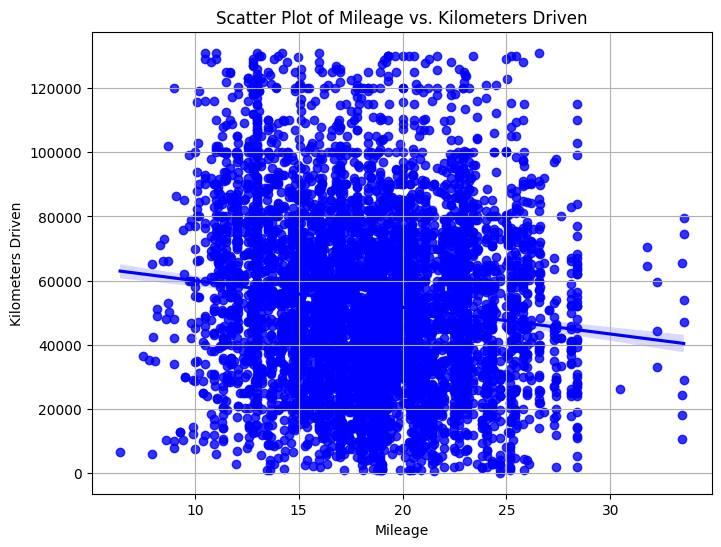

In [ ]:
# 산점도와 회귀선 그리기
plt.figure(figsize=(8, 6))
sns.regplot(x=df['Mileage'], y=df['Kilometers_Driven'], color='blue')
plt.title('Scatter Plot of Mileage vs. Kilometers Driven')
plt.xlabel('Mileage')
plt.ylabel('Kilometers Driven')
plt.grid(True)
plt.show()

mileage가 증가할수록 kilometers driven(차량 주행거리)가 감소하는 경향성을 보입니다。

### 2) vehicle age와의 비교

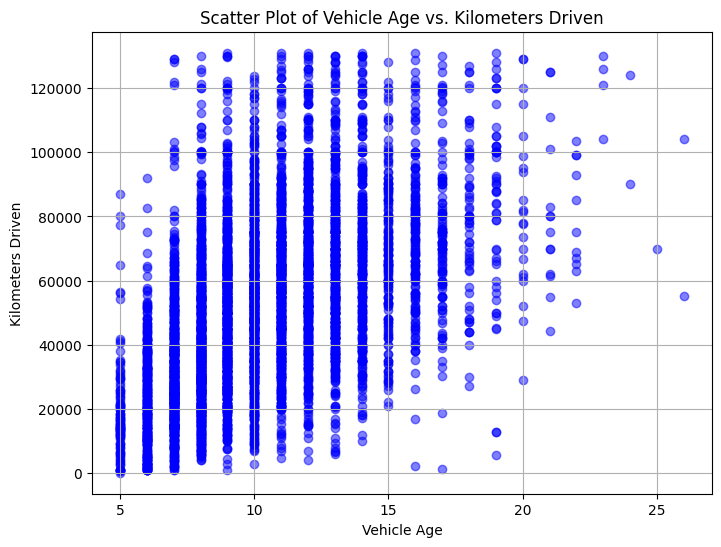

In [ ]:
# 산점도 그리기
plt.figure(figsize=(8, 6))
plt.scatter(df['Vehicle_Age'], df['Kilometers_Driven'], color='blue', alpha=0.5)
plt.title('Scatter Plot of Vehicle Age vs. Kilometers Driven')
plt.xlabel('Vehicle Age')
plt.ylabel('Kilometers Driven')
plt.grid(True)
plt.show()

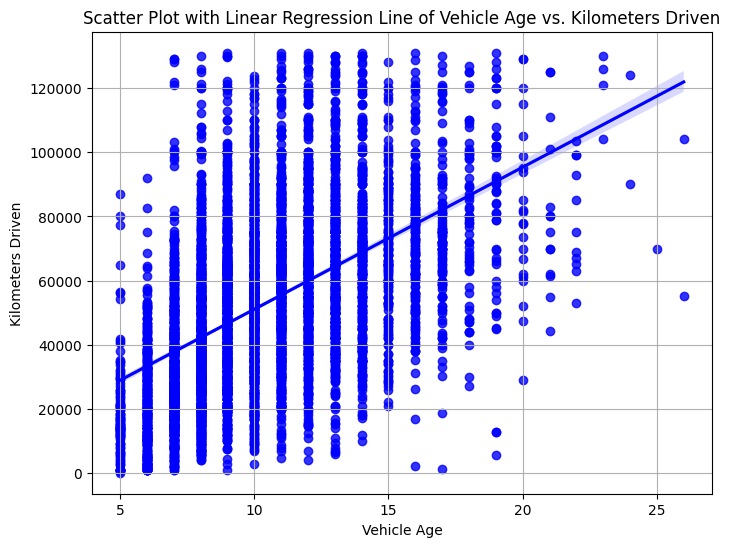

In [ ]:
# 산점도와 회귀선 그리기
plt.figure(figsize=(8, 6))
sns.regplot(x=df['Vehicle_Age'], y=df['Kilometers_Driven'], color='blue')
plt.title('Scatter Plot with Linear Regression Line of Vehicle Age vs. Kilometers Driven')
plt.xlabel('Vehicle Age')
plt.ylabel('Kilometers Driven')
plt.grid(True)
plt.show()

연식이 높아질수록 kilometers driven이 증가하는 것을 관찰할 수 있습니다。

### 3) Age와의 비교

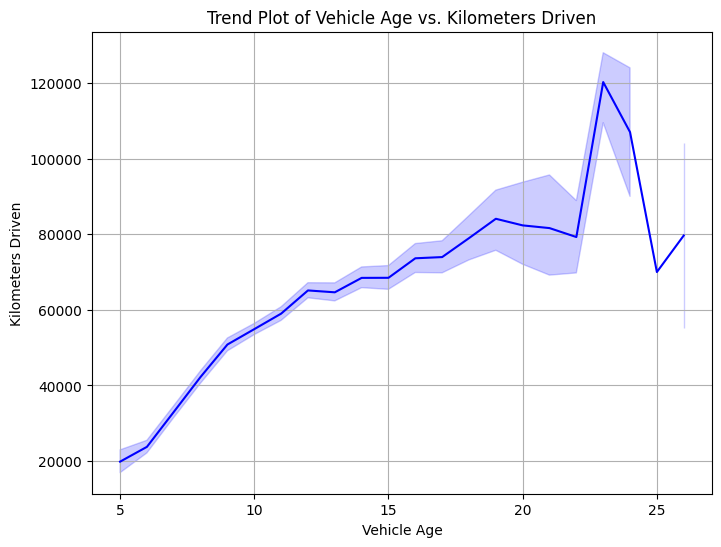

In [ ]:
# vehicle age와 kilometers Driven trend Plot 그리기
plt.figure(figsize=(8, 6))
sns.lineplot(x=df['Vehicle_Age'], y=df['Kilometers_Driven'], color='blue')
plt.title('Trend Plot of Vehicle Age vs. Kilometers Driven')
plt.xlabel('Vehicle Age')
plt.ylabel('Kilometers Driven')
plt.grid(True)
plt.show()


vehicle age가 높을수록 kilometers driven이 증가하는 경향을 보입니다。

### 4) price와의 비교  

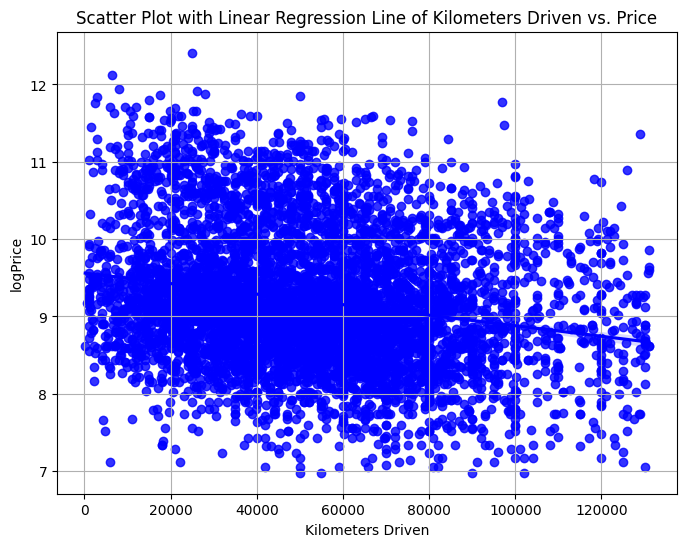

In [ ]:
import seaborn as sns

# 산점도와 선형 회귀선 그리기
plt.figure(figsize=(8, 6))
sns.regplot(x=df['Kilometers_Driven'], y=df['log_price'], color='blue')
plt.title('Scatter Plot with Linear Regression Line of Kilometers Driven vs. Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('logPrice')
plt.grid(True)
plt.show()


kilometers driven이 증가할수록 price가 감소하는 경향을 보입니다。

#### price와 kilometers driven 간 관계에 상관성이 있는지 검정

In [ ]:
from scipy.stats import pearsonr
import numpy as np

# 정규성 검정
shapiro_test_result_kilometers = shapiro(df['Kilometers_Driven'])
shapiro_test_result_log_price = shapiro(df['log_price'])

# 정규성 검정 결과 출력
print("Shapiro-Wilk Test for Kilometers_Driven:")
print("Statistic:", shapiro_test_result_kilometers.statistic)
print("p-value:", shapiro_test_result_kilometers.pvalue)
print("\nShapiro-Wilk Test for log_price:")
print("Statistic:", shapiro_test_result_log_price.statistic)
print("p-value:", shapiro_test_result_log_price.pvalue)

# 선형성과 등분산성 검정
if (shapiro_test_result_kilometers.pvalue > 0.05) and (shapiro_test_result_log_price.pvalue > 0.05):
    # Pearson 상관 계수 계산
    pearson_corr, p_value = pearsonr(df['Kilometers_Driven'], df['log_price'])

    # 결과 출력
    print("\nPearson Correlation Coefficient:", pearson_corr)
    print("p-value:", p_value)
else:
    print("Variables do not meet the assumptions for Pearson correlation analysis.")


Shapiro-Wilk Test for Kilometers_Driven:
Statistic: 0.9818933606147766
p-value: 5.8098900779167874e-27

Shapiro-Wilk Test for log_price:
Statistic: 0.9784542322158813
p-value: 3.724065710094318e-29
Variables do not meet the assumptions for Pearson correlation analysis.


In [ ]:
from scipy.stats import spearmanr

# 스피어만 상관 계수 계산
spearman_corr, p_value = spearmanr(df['Kilometers_Driven'], df['log_price'])

# 결과 출력
print("Spearman's Rank Correlation Coefficient:", spearman_corr)
print("p-value:", p_value)


Spearman's Rank Correlation Coefficient: -0.20921590923562908
p-value: 4.359140979948796e-60


- 두 변수 간의 관계는 통계적으로 유의합니다.
- 상관 계수의 부호인 음수는 두 변수 사이에 약한 음의 선형 관계가 있음을 나타냅니다. 즉, "Kilometers_Driven"이 증가할 때 "log_price"는 감소하는 경향이 있습니다. \
따라서 "Kilometers_Driven"과 "log_price" 사이에는 약한 음의 상관 관계가 있다고 결론지을 수 있습니다.

## Mileage

### 데이터 분포 확인

<Axes: xlabel='Mileage', ylabel='Count'>

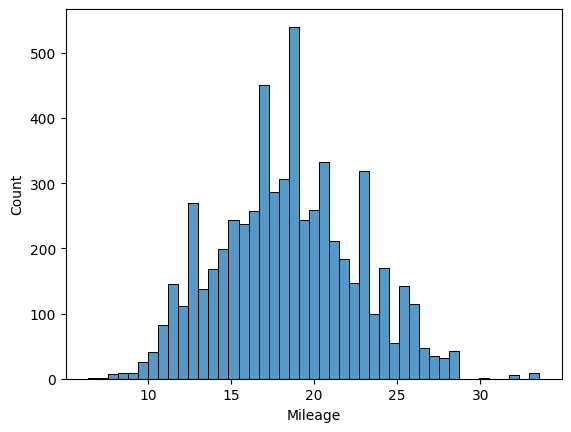

In [ ]:
# df.hist method 이용 : Kilometers_Driven에 대한 히스토그램 생성
sns.histplot(data=df, x="Mileage")

<Axes: xlabel='Mileage'>

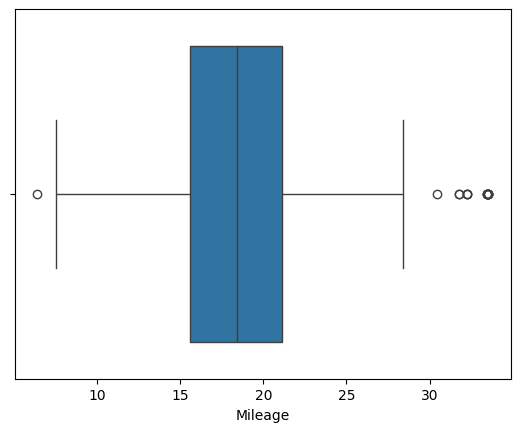

In [ ]:
# kilometer_Driven boxplot
sns.boxplot(x='Mileage', data=df)

1) Vehicle Age와의 비교

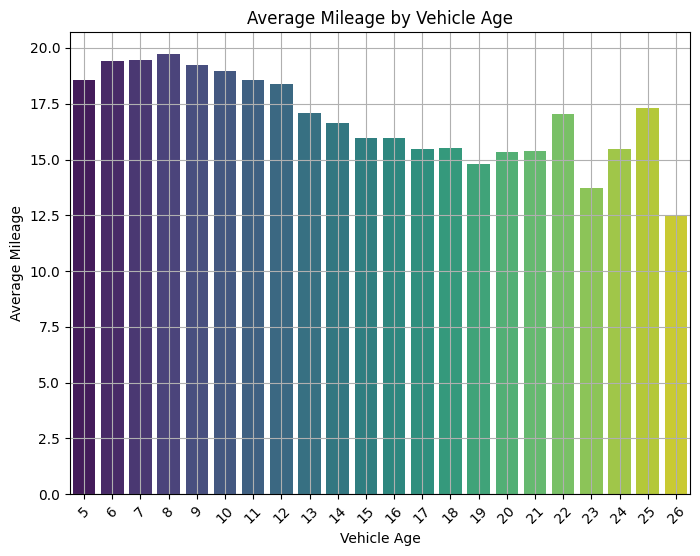

In [ ]:
# Vehicle_Age에 따른 Mileage의 평균 계산
mileage_by_age = df.groupby('Vehicle_Age')['Mileage'].mean().reset_index()

# 그래프 그리기
plt.figure(figsize=(8, 6))
sns.barplot(x='Vehicle_Age', y='Mileage', data=mileage_by_age, palette='viridis')
plt.title('Average Mileage by Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

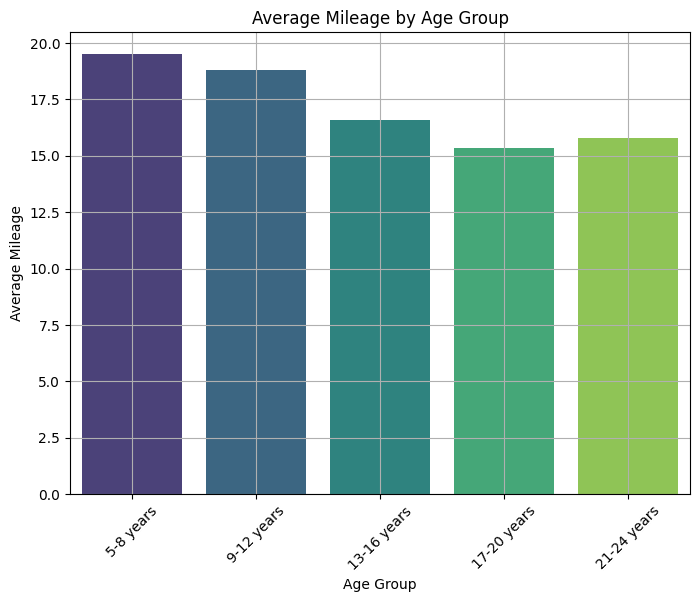

In [ ]:
# Vehicle_Age를 구간으로 변환
bins = np.arange(5, 29, 4)
labels = ['{}-{} years'.format(start, start + 3) for start in bins[:-1]]  # labels의 마지막 요소 제거
df['Age_Group'] = pd.cut(df['Vehicle_Age'], bins=bins, labels=labels, right=False)

# Age_Group에 따른 Mileage의 평균 계산
mileage_by_age_group = df.groupby('Age_Group')['Mileage'].mean().reset_index()

# 그래프 그리기
plt.figure(figsize=(8, 6))
sns.barplot(x='Age_Group', y='Mileage', data=mileage_by_age_group, palette='viridis')
plt.title('Average Mileage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


vehicle age(현재 연도-제조년도)가 클수록 mileage가 감소하는 경향이 보인다.

### 2) price와의 비교

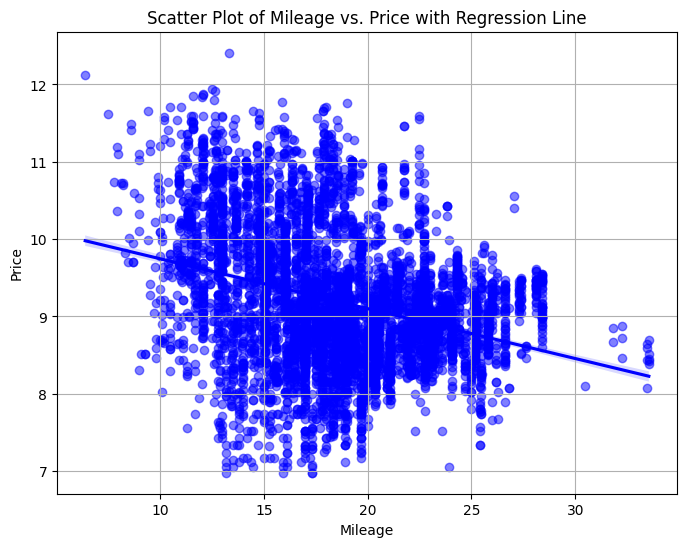

In [ ]:
# 산점도와 회귀선 그리기
plt.figure(figsize=(8, 6))
sns.regplot(x='Mileage', y='log_price', data=df, color='blue', scatter_kws={'alpha':0.5})
plt.title('Scatter Plot of Mileage vs. Price with Regression Line')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Mileage가 증가할수록 가격이 감소하는 경향을 보입니다。

#### price와 mileage간의 상관성 확인

In [ ]:
from scipy.stats import pearsonr
import numpy as np

# 정규성 검정
shapiro_test_result_kilometers = shapiro(df['Mileage'])
shapiro_test_result_log_price = shapiro(df['log_price'])

# 정규성 검정 결과 출력
print("Shapiro-Wilk Test for Mileage:")
print("Statistic:", shapiro_test_result_kilometers.statistic)
print("p-value:", shapiro_test_result_kilometers.pvalue)
print("\nShapiro-Wilk Test for log_price:")
print("Statistic:", shapiro_test_result_log_price.statistic)
print("p-value:", shapiro_test_result_log_price.pvalue)

# 선형성과 등분산성 검정
if (shapiro_test_result_kilometers.pvalue > 0.05) and (shapiro_test_result_log_price.pvalue > 0.05):
    # Pearson 상관 계수 계산
    pearson_corr, p_value = pearsonr(df['Mileage'], df['log_price'])

    # 결과 출력
    print("\nPearson Correlation Coefficient:", pearson_corr)
    print("p-value:", p_value)
else:
    print("Variables do not meet the assumptions for Pearson correlation analysis.")


Shapiro-Wilk Test for Mileage:
Statistic: 0.9935755133628845
p-value: 9.018016741072898e-16

Shapiro-Wilk Test for log_price:
Statistic: 0.9784542322158813
p-value: 3.724065710094318e-29
Variables do not meet the assumptions for Pearson correlation analysis.


In [ ]:
from scipy.stats import spearmanr

# 스피어만 상관 계수 계산
spearman_corr, p_value = spearmanr(df['Mileage'], df['log_price'])

# 결과 출력
print("Spearman's Rank Correlation Coefficient:", spearman_corr)
print("p-value:", p_value)


Spearman's Rank Correlation Coefficient: -0.2929524719786259
p-value: 1.4650214236317797e-118


- 두 변수 간의 관계는 통계적으로 유의합니다.
- 상관 계수의 부호인 음수는 두 변수 사이에 약한 음의 선형 관계가 있음을 나타냅니다. 즉, "Mileage"가 증가할 때 "log_price"는 감소하는 경향이 있습니다.\
따라서 "Mileage"와 "log_price" 사이에는 약한 음의 상관 관계가 있다고 결론지을 수 있습니다。

### 3) Brand 간의 비교

In [ ]:
df_pajon=pd.read_csv("/content/drive/MyDrive/인도 중고차 /박주형/pajon.csv")
df_pajon

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,2,1,1,26.60,998.0,58.16,5.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,0,1,1,19.67,1582.0,126.20,5.0
2,Honda Jazz V,Chennai,6898.32,2011,46000,1,1,1,18.20,1199.0,88.70,5.0
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,0,1,1,20.77,1248.0,88.76,7.0
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,0,2,2,15.20,1968.0,140.80,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6987,Volkswagen Vento Diesel Trendline,Hyderabad,NaN,2011,89411,0,1,1,20.54,1598.0,103.60,5.0
6988,Volkswagen Polo GT TSI,Mumbai,NaN,2015,59000,1,2,1,17.21,1197.0,103.60,5.0
6989,Nissan Micra Diesel XV,Kolkata,NaN,2012,28000,0,1,1,23.08,1461.0,63.10,5.0
6990,Volkswagen Polo GT TSI,Pune,NaN,2013,52262,1,2,3,17.20,1197.0,103.60,5.0


In [ ]:
df_pajon['Brand'] = df_pajon.Name.apply(lambda x:x.split()[0])

In [ ]:
brand_count = df_pajon['Brand'].nunique()
print('차 브랜드 개수 : {}'.format(brand_count))

unique_brands = df_pajon['Brand'].unique()
print(unique_brands)

차 브랜드 개수 : 32
['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'ISUZU' 'Force' 'Bentley' 'Lamborghini'
 'Hindustan' 'OpelCorsa']


In [ ]:
brand_groups = { #브랜드 등급별로 분류
    'GeneralBrands': ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Nissan', 'Tata', 'Mitsubishi', 'Renault', 'Mahindra',
                       'Chevrolet', 'Skoda', 'Fiat', 'Jeep', 'Ambassador', 'ISUZU', 'Force', 'Hindustan'], #일반 브랜드
    'PremiumBrands': ['Audi', 'Volkswagen', 'Porsche', 'Mercedes-Benz', 'BMW', 'Jaguar', 'Volvo', 'Land', 'Bentley', 'Lamborghini'], #프리미엄 브랜드
    'CompactBrands': ['Datsun', 'Mini', 'Smart', 'OpelCorsa'] #소형 브랜드
}

df_pajon['Brand_Group'] = df_pajon['Brand'].map({brand: group for group, brands in brand_groups.items() for brand in brands})

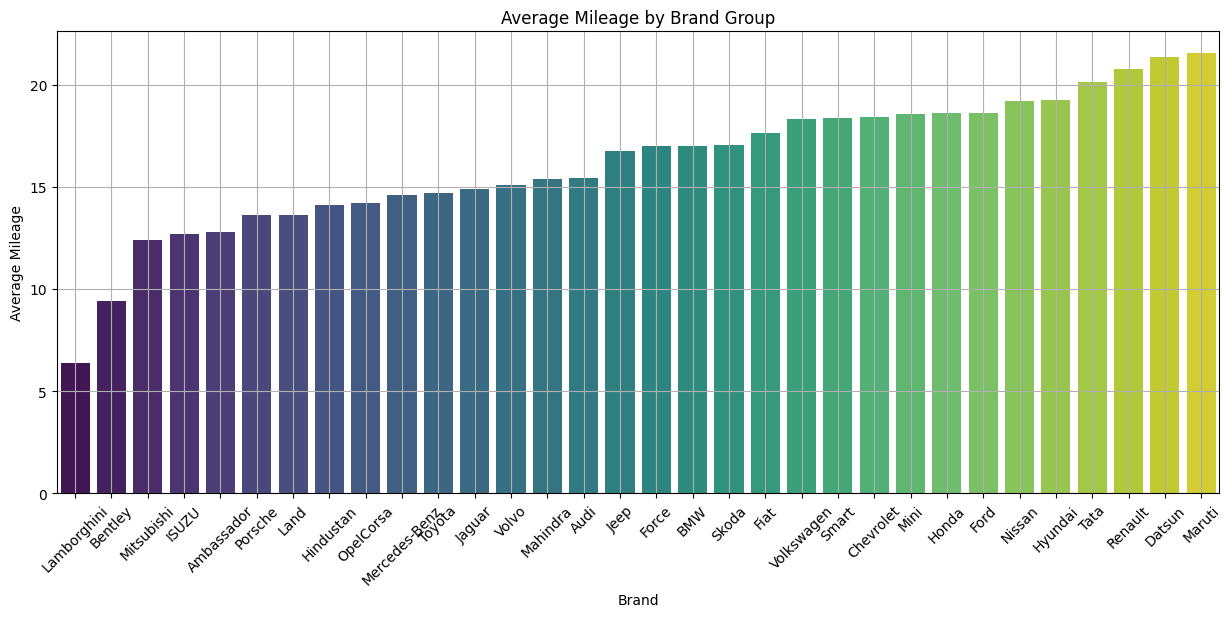

In [ ]:
# 브랜드 그룹별로 Mileage 계산
mileage_by_brand_group = df_pajon.groupby('Brand')['Mileage'].mean().reset_index()

# 브랜드 그룹별로 평균 Mileage를 기준으로 정렬
mileage_by_brand_group_sorted = mileage_by_brand_group.sort_values(by='Mileage')

# 그래프 그리기
plt.figure(figsize=(15, 6))
sns.barplot(x='Brand', y='Mileage', data=mileage_by_brand_group_sorted, palette='viridis')
plt.title('Average Mileage by Brand Group')
plt.xlabel('Brand')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

브랜드 별 Mileage 현황

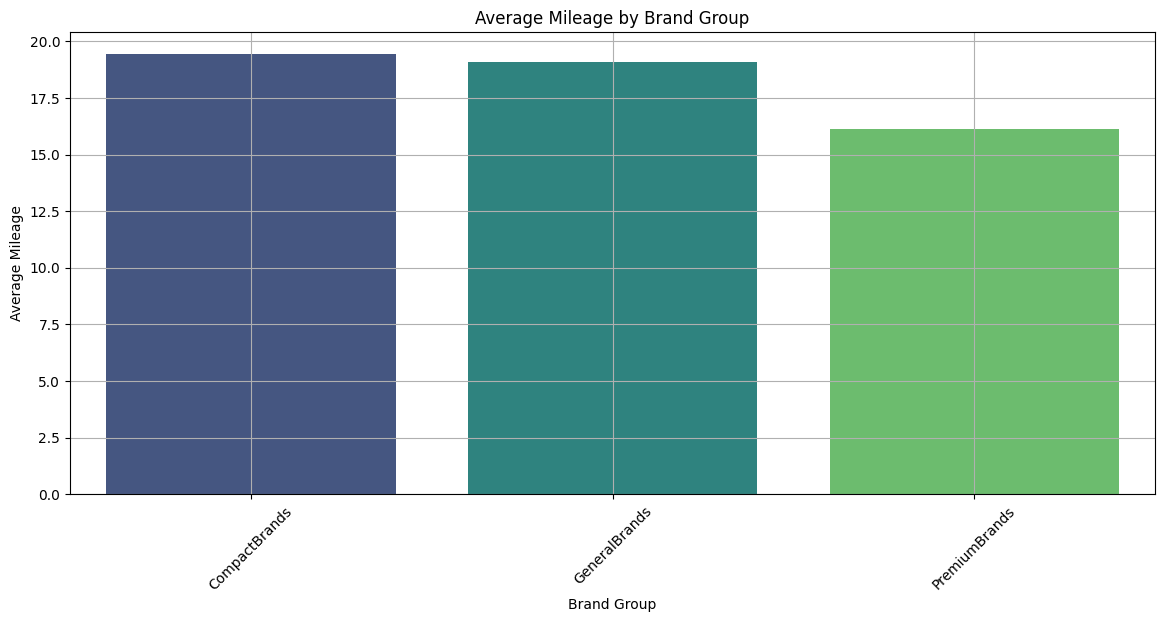

In [ ]:
# 브랜드 그룹별로 Mileage 계산
mileage_by_brand_group = df_pajon.groupby('Brand_Group')['Mileage'].mean().reset_index()

# 그래프 그리기
plt.figure(figsize=(14, 6))
sns.barplot(x='Brand_Group', y='Mileage', data=mileage_by_brand_group, palette='viridis')
plt.title('Average Mileage by Brand Group')
plt.xlabel('Brand Group')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

고가의 브랜드일수록 mileage 평균이 낮아지는 경향을 보입니다。

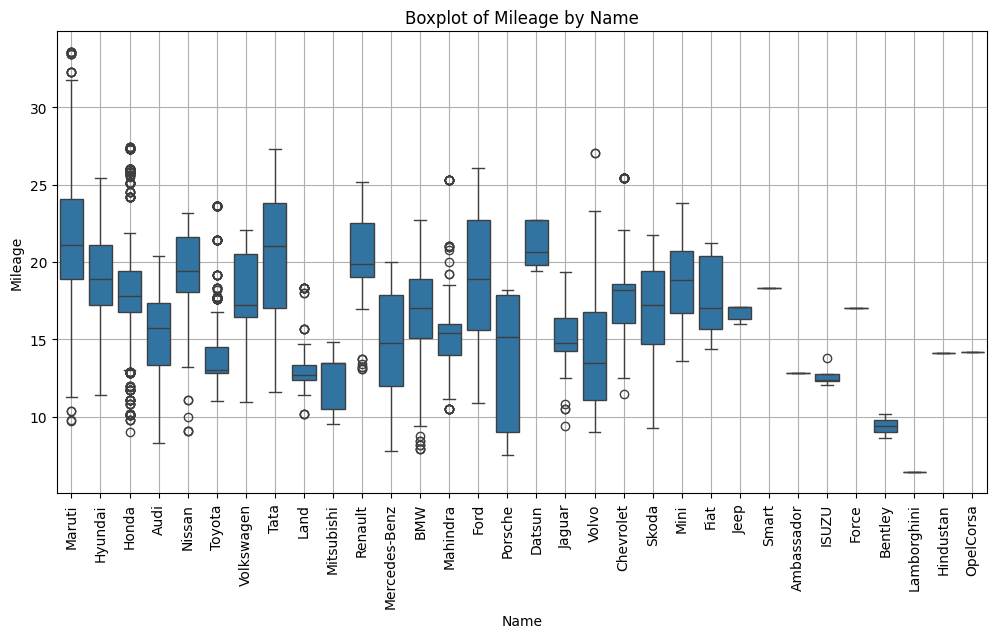

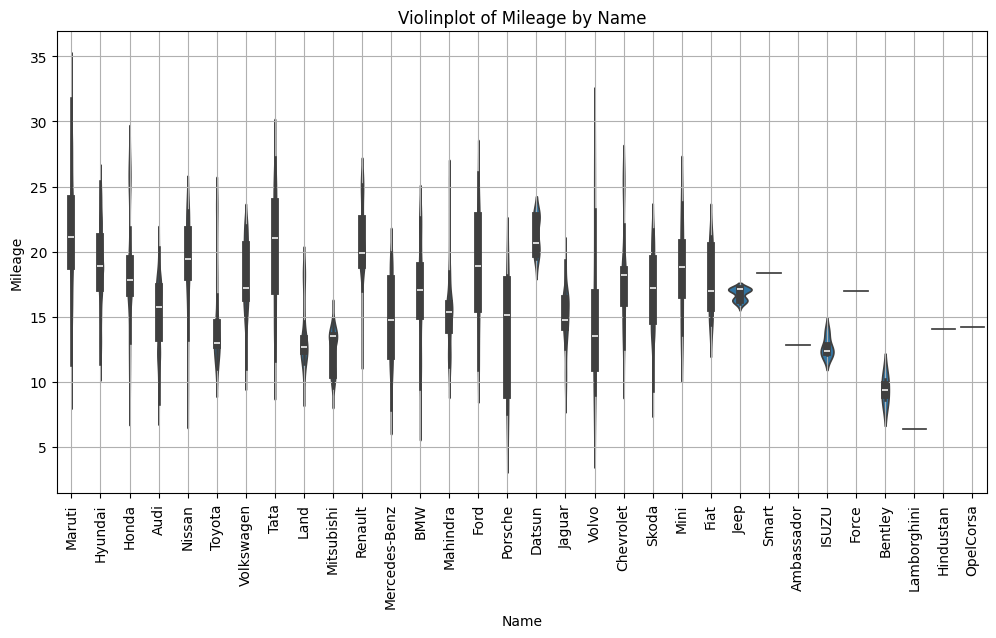

In [ ]:
# boxplot 그리기
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Mileage', data=df_pajon)
plt.title('Boxplot of Mileage by Name')
plt.xlabel('Name')
plt.ylabel('Mileage')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# violinplot 그리기
plt.figure(figsize=(12, 6))
sns.violinplot(x='Brand', y='Mileage', data=df_pajon)
plt.title('Violinplot of Mileage by Name')
plt.xlabel('Name')
plt.ylabel('Mileage')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()